## Amazon Bestselling Books (2009-2019) - Data Analyst Project
### Phase 0: Setup & Dataset Inspection

In [6]:
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize

# Download dataset if using KaggleHub (skip if using local)
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")
print("Path to dataset files:", path)

C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\shiva\.cache\kagglehub\datasets\sootersaalu\amazon-top-50-bestselling-books-2009-2019\versions\1


In [7]:
# Load dataset
file_path = r"C:\Users\shiva\Downloads\amazon best seller\bestsellers with categories.csv"
df = pd.read_csv(file_path)
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

### Phase 1: Cleaning & Basic EDA

In [8]:
df.duplicated().sum()  # No duplicates found

np.int64(0)

In [9]:
df.Author.value_counts().head(5)  # Top 5 most frequent authors

Author
Jeff Kinney                           12
Suzanne Collins                       11
Gary Chapman                          11
Rick Riordan                          11
American Psychological Association    10
Name: count, dtype: int64

In [10]:
df.Genre.value_counts()  # Fiction vs Non-Fiction

Genre
Non Fiction    310
Fiction        240
Name: count, dtype: int64

In [11]:
df.nunique()  # Unique values per column

Name           351
Author         248
User Rating     14
Reviews        346
Price           40
Year            11
Genre            2
dtype: int64

In [12]:
df = df.drop_duplicates(subset=["Name", "User Rating", "Reviews"])
df.sort_values(by="Reviews", ascending=False).head(10)

,Name,Author,User Rating,Reviews,Price,Year,Genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction
382,The Girl on the Train,Paula Hawkins,4.1,79446,18,2015,Fiction
32,Becoming,Michelle Obama,4.8,61133,11,2018,Non Fiction
135,Gone Girl,Gillian Flynn,4.0,57271,10,2012,Fiction
365,The Fault in Our Stars,John Green,4.7,50482,13,2012,Fiction
437,The Nightingale: A Novel,Kristin Hannah,4.8,49288,11,2015,Fiction
106,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,3.8,47265,14,2012,Fiction
433,The Martian,Andy Weir,4.7,39459,9,2015,Fiction
20,All the Light We Cannot See,Anthony Doerr,4.6,36348,14,2014,Fiction
338,The Alchemist,Paulo Coelho,4.7,35799,39,2014,Fiction



### Phase 2: KPI Analysis – Real Business Questions

In [13]:
# Most reviewed books
most_reviewed = df.sort_values(by="Reviews", ascending=False)[["Name", "Author", "Reviews"]].head(10)
most_reviewed

,Name,Author,Reviews
534,Where the Crawdads Sing,Delia Owens,87841
382,The Girl on the Train,Paula Hawkins,79446
32,Becoming,Michelle Obama,61133
135,Gone Girl,Gillian Flynn,57271
365,The Fault in Our Stars,John Green,50482
437,The Nightingale: A Novel,Kristin Hannah,49288
106,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,47265
433,The Martian,Andy Weir,39459
20,All the Light We Cannot See,Anthony Doerr,36348
338,The Alchemist,Paulo Coelho,35799


In [14]:
# Which Authors Have the Most Bestsellers?
top_authors = df["Author"].value_counts().head(10)
top_authors

Author
Jeff Kinney        12
Rick Riordan       10
Stephenie Meyer     7
Dav Pilkey          6
Bill O'Reilly       6
J.K. Rowling        6
Suzanne Collins     5
E L James           5
John Grisham        5
Stieg Larsson       4
Name: count, dtype: int64

<Axes: title={'center': 'Avg_ratings_per_year'}, xlabel='Year'>

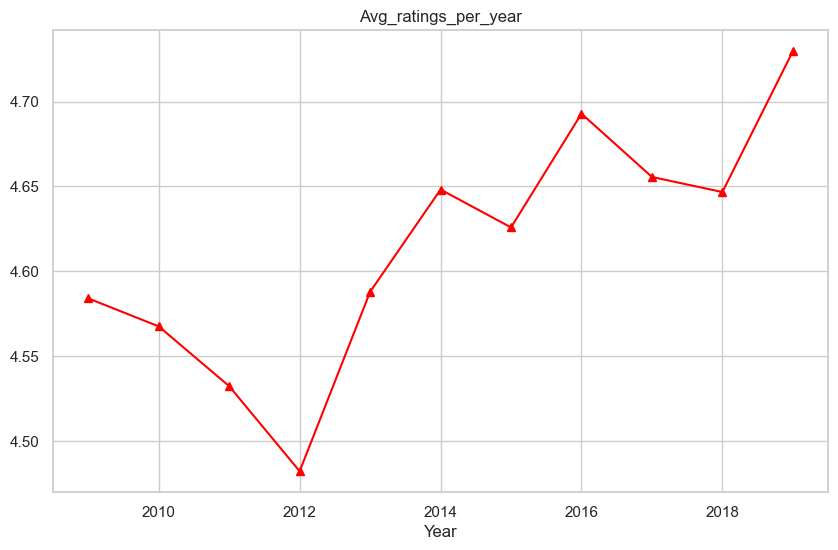

In [15]:
# Average Rating Per Year
avg_rating_by_year = df.groupby('Year')['User Rating'].mean()
avg_rating_by_year.plot(kind="line", marker="^", title="Avg_ratings_per_year", color="red")

Text(0.5, 1.0, 'Price Trends over the Years')

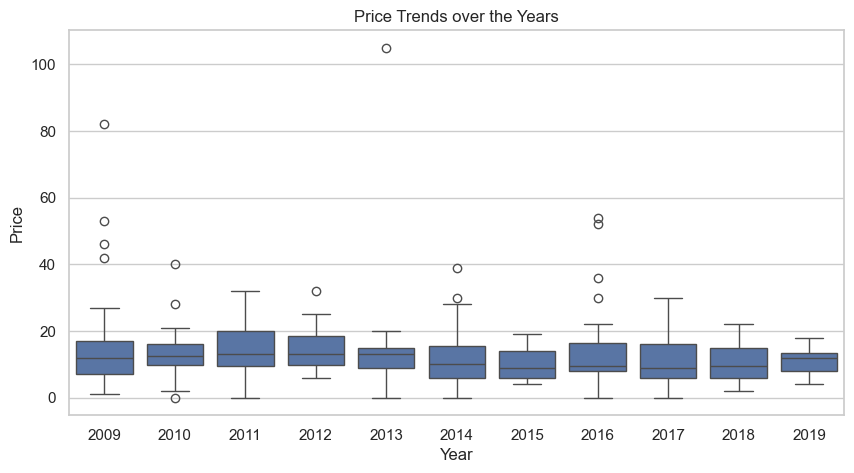

In [16]:
# Price trend over the years
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Year", y="Price")
plt.title("Price Trends over the Years")

<Axes: title={'center': 'Fiction vs Non-Fiction'}, ylabel='count'>

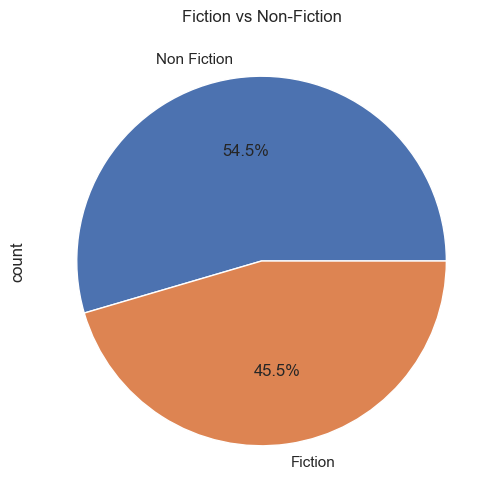

In [17]:
df["Genre"].value_counts().plot(kind="pie", autopct='%1.1f%%', title="Fiction vs Non-Fiction")

### Phase 3: Visualization Mastery

C:\Users\shiva\AppData\Local\Temp\ipykernel_3332\2715671728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette="viridis")


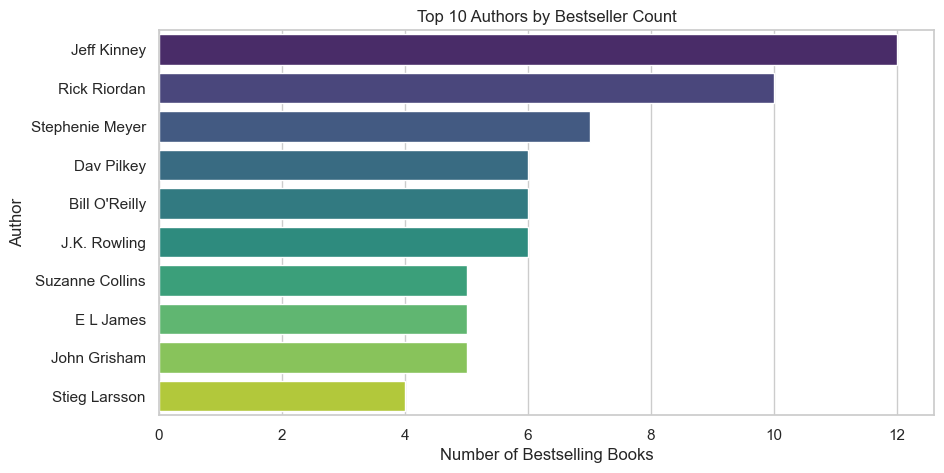

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_authors.values, y=top_authors.index, palette="viridis")
plt.title("Top 10 Authors by Bestseller Count")
plt.xlabel("Number of Bestselling Books")
plt.ylabel("Author")
plt.show()

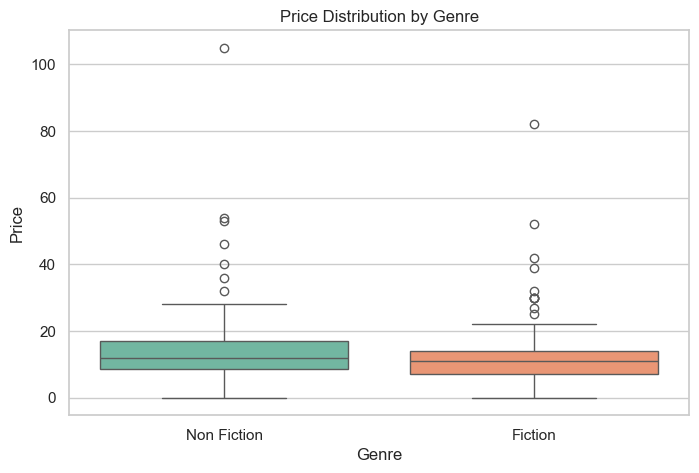

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Genre", y="Price", data=df, palette="Set2", hue="Genre", legend=False)
plt.title("Price Distribution by Genre")
plt.show()

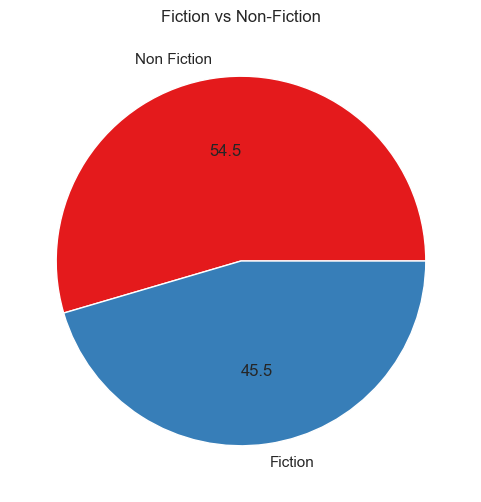

In [20]:
plt.figure(figsize=(6, 6))
genre_counts = df.Genre.value_counts()
plt.pie(genre_counts, labels=genre_counts.index, autopct="%1.1f", colors=sns.color_palette("Set1"))
plt.title("Fiction vs Non-Fiction")
plt.show()

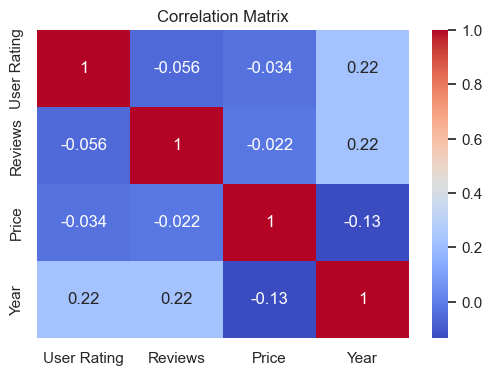

In [21]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Phase 4: Pandas Deep Dive (GroupBy, Pivot, Apply, Filter)

In [22]:
df.groupby("Year")["User Rating"].mean().reset_index().sort_values(by="Year", ascending=False)

,Year,User Rating
10,2019,4.729630
9,2018,4.646667
8,2017,4.655556
7,2016,4.692857
6,2015,4.625806
5,2014,4.648148
4,2013,4.587879
3,2012,4.482143
2,2011,4.532258
1,2010,4.567500


In [23]:
df["Year"].value_counts().sort_index()

Year
2009    50
2010    40
2011    31
2012    28
2013    33
2014    27
2015    31
2016    28
2017    27
2018    30
2019    27
Name: count, dtype: int64

In [24]:
df.groupby("Author")["Reviews"].sum().sort_values(ascending=False)

Author
E L James            130746
Suzanne Collins      130548
Delia Owens           87841
Paula Hawkins         79446
J.K. Rowling          70535
                      ...  
Larry Schweikart        460
Jon Stewart             440
Edward M. Kennedy       438
Peter A. Lillback       408
Zhi Gang Sha            257
Name: Reviews, Length: 248, dtype: int64

In [25]:
df.groupby("Genre")["Price"].mean()

Genre
Fiction        12.156250
Non Fiction    13.859375
Name: Price, dtype: float64

In [26]:
df[(df["User Rating"] > 3.5) & (df["Reviews"] > 50000)][['Name', 'Author', "User Rating", "Reviews"]].sort_values(by="User Rating")

,Name,Author,User Rating,Reviews
135,Gone Girl,Gillian Flynn,4.0,57271
382,The Girl on the Train,Paula Hawkins,4.1,79446
365,The Fault in Our Stars,John Green,4.7,50482
32,Becoming,Michelle Obama,4.8,61133
534,Where the Crawdads Sing,Delia Owens,4.8,87841


In [27]:
df.groupby("Genre")["User Rating"].mean().sort_values()

Genre
Non Fiction    4.603646
Fiction        4.615625
Name: User Rating, dtype: float64

In [28]:
genre_stats = df.groupby("Genre").agg({
    "User Rating": "mean",
    "Reviews": "sum",
    "Price": "max"
})
genre_stats

,User Rating,Reviews,Price
Genre,,,
Fiction,4.615625,2097771,82
Non Fiction,4.603646,1346643,105


In [29]:
authors_high_user_ratings = df.groupby("Author").agg({
    "Name": "count",
    "User Rating": "mean",
    "Reviews": "sum"
})
authors_high_user_ratings

,Name,User Rating,Reviews
Author,,,
Abraham Verghese,1,4.60,4866
Adam Gasiewski,1,4.40,3113
Adam Mansbach,1,4.80,9568
Adir Levy,1,4.80,8170
Admiral William H. McRaven,1,4.70,10199
...,...,...,...
Walter Isaacson,2,4.55,10841
William Davis,1,4.40,7497
William P. Young,1,4.60,19720


<Axes: title={'center': 'Yearly Trends'}, xlabel='Year'>

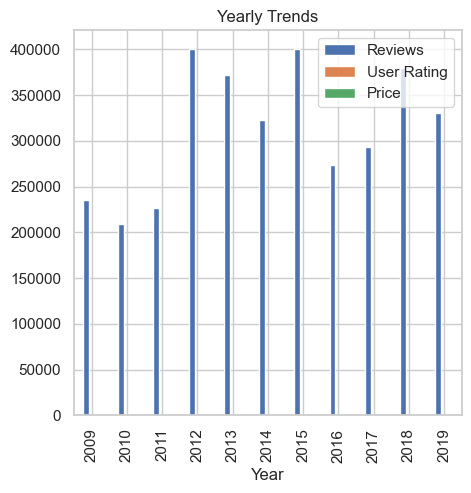

In [30]:
year_trends = df.groupby("Year").agg({
    "Reviews": "sum",
    "User Rating": "mean",
    "Price": "mean"
}).round(2).sort_index()
year_trends.plot(kind='bar', figsize=(5, 5), title="Yearly Trends")

In [31]:
df.groupby("Genre").agg({
    "User Rating": "mean",
    "Reviews": "sum",
    "Price": "mean"
}).round(2)

,User Rating,Reviews,Price
Genre,,,
Fiction,4.62,2097771,12.16
Non Fiction,4.60,1346643,13.86


<Axes: title={'center': 'Total Reviews per Genre per Year'}, xlabel='Year'>

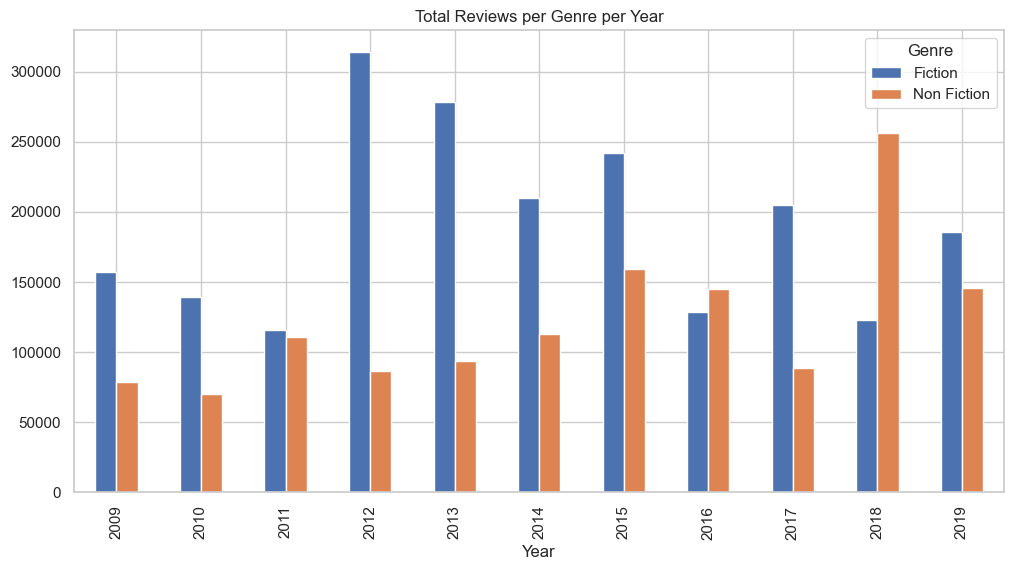

In [32]:
genre_year_reviews = pd.pivot_table(
    data=df,
    index="Genre",
    columns="Year",
    values="Reviews",
    aggfunc="sum"
)
genre_year_reviews.T.plot(kind="bar", figsize=(12, 6), title="Total Reviews per Genre per Year")

<Axes: title={'center': 'Average User Ratings per Genre per Year'}, xlabel='Year'>

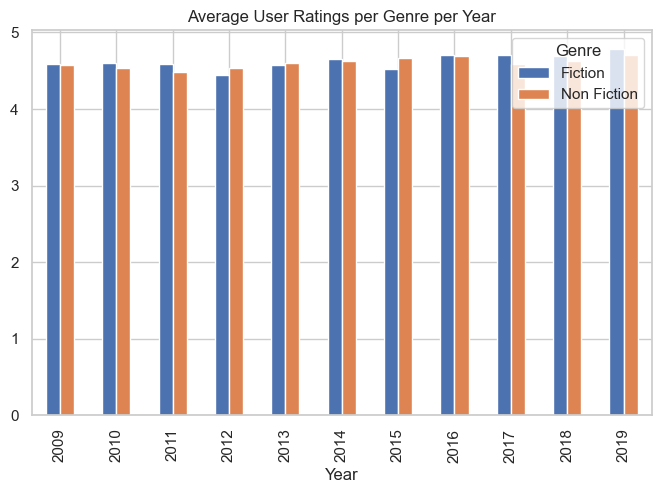

In [33]:


avg_user_ratings = pd.pivot_table(
    data=df,
    index="Genre",
    columns="Year",
    values="User Rating",
    aggfunc="mean"
)
avg_user_ratings.T.plot(kind="bar", figsize=(8, 5), title="Average User Ratings per Genre per Year")

In [34]:
author_year_count = df.groupby("Author")["Year"].nunique()
top_authors_3 = author_year_count[author_year_count >= 3].index
df_top = df[df["Author"].isin(top_authors_3)]

pd.pivot_table(
    df_top,
    index="Author",
    columns="Year",
    values="Price",
    aggfunc="mean"
)

Year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
Author,,,,,,,,,,,
Bill O'Reilly,NaN,NaN,10.0,25.0,12.0,6.0,5.0,6.00,NaN,NaN,NaN
Charlaine Harris,14.5,8.000000,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dan Brown,19.0,NaN,NaN,NaN,14.0,NaN,NaN,NaN,13.0,NaN,NaN
Dav Pilkey,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,5.333333,8.0
Gary Chapman,9.0,28.000000,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN
Ina Garten,NaN,21.000000,NaN,24.0,NaN,20.0,NaN,NaN,NaN,NaN,NaN
J.K. Rowling,NaN,NaN,NaN,12.0,NaN,NaN,NaN,19.75,30.0,NaN,NaN
Jeff Kinney,13.5,12.000000,0.0,7.0,0.0,22.0,7.0,20.00,0.0,8.000000,8.0
John Grisham,NaN,13.000000,18.0,18.0,18.0,NaN,NaN,NaN,NaN,NaN,14.0


In [35]:
author_with_more_books = df.groupby("Author").filter(lambda x: len(x) >= 3)
author_with_more_books

,Name,Author,User Rating,Reviews,Price,Year,Genre
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
22,Allegiant,Veronica Roth,3.9,6310,13,2013,Fiction
25,Arguing with Idiots: How to Stop Small Minds a...,Glenn Beck,4.6,798,5,2009,Non Fiction
30,Barefoot Contessa Foolproof: Recipes You Can T...,Ina Garten,4.8,1296,24,2012,Non Fiction
31,"Barefoot Contessa, How Easy Is That?: Fabulous...",Ina Garten,4.7,615,21,2010,Non Fiction
...,...,...,...,...,...,...,...
473,The Twilight Saga Collection,Stephenie Meyer,4.7,3801,82,2009,Fiction
474,"The Ugly Truth (Diary of a Wimpy Kid, Book 5)",Jeff Kinney,4.8,3796,12,2010,Fiction
513,"Twilight (The Twilight Saga, Book 1)",Stephenie Meyer,4.7,11676,9,2009,Fiction
520,Under the Dome: A Novel,Stephen King,4.3,6740,20,2009,Fiction


In [36]:
df.groupby("Year").filter(lambda x: x["Reviews"].sum() > 100000)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
538,Winter of the World: Book Two of the Century T...,Ken Follett,4.5,10760,15,2012,Fiction
539,Women Food and God: An Unexpected Path to Almo...,Geneen Roth,4.2,1302,11,2010,Non Fiction
540,Wonder,R. J. Palacio,4.8,21625,9,2013,Fiction
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction


In [37]:
df.groupby("Genre").filter(lambda x: x["Price"].mean() > 13)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
11,A Patriot's History of the United States: From...,Larry Schweikart,4.6,460,2,2010,Non Fiction
...,...,...,...,...,...,...,...
533,When Breath Becomes Air,Paul Kalanithi,4.8,13779,14,2016,Non Fiction
536,Whose Boat Is This Boat?: Comments That Don't ...,The Staff of The Late Show with,4.6,6669,12,2018,Non Fiction
537,Wild: From Lost to Found on the Pacific Crest ...,Cheryl Strayed,4.4,17044,18,2012,Non Fiction
539,Women Food and God: An Unexpected Path to Almo...,Geneen Roth,4.2,1302,11,2010,Non Fiction


In [38]:
df["Expensive"] = df.apply(lambda row: row["Price"] > 16, axis=1)

In [39]:
df.groupby("Author").apply(lambda x: x.loc[x["Reviews"].idxmax()])

C:\Users\shiva\AppData\Local\Temp\ipykernel_3332\180566403.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("Author").apply(lambda x: x.loc[x["Reviews"].idxmax()])


,Name,Author,User Rating,Reviews,Price,Year,Genre,Expensive
Author,,,,,,,,
Abraham Verghese,Cutting for Stone,Abraham Verghese,4.6,4866,11,2010,Fiction,False
Adam Gasiewski,Milk and Vine: Inspirational Quotes From Class...,Adam Gasiewski,4.4,3113,6,2017,Non Fiction,False
Adam Mansbach,Go the F**k to Sleep,Adam Mansbach,4.8,9568,9,2011,Fiction,False
Adir Levy,What Should Danny Do? (The Power to Choose Ser...,Adir Levy,4.8,8170,13,2019,Fiction,False
Admiral William H. McRaven,Make Your Bed: Little Things That Can Change Y...,Admiral William H. McRaven,4.7,10199,11,2017,Non Fiction,False
...,...,...,...,...,...,...,...,...
Walter Isaacson,Steve Jobs,Walter Isaacson,4.6,7827,20,2011,Non Fiction,True
William Davis,"Wheat Belly: Lose the Wheat, Lose the Weight, ...",William Davis,4.4,7497,6,2012,Non Fiction,False
William P. Young,The Shack: Where Tragedy Confronts Eternity,William P. Young,4.6,19720,8,2009,Fiction,False


### Numpy (percentile,argmax,zscore,nunique,random)

In [40]:
# Identify books in the top 10% of reviews to feature or give marketing push.
review_cutoff=np.percentile(df["Reviews"],90)
#Tag top 10% books

df["Top10_Review"] = np.where(df["Reviews"] >= review_cutoff, "Top 10%", "Others") #np.where() creates a new column like an Excel IF formula.
df[["Name", "Author", "Reviews", "Top10_Review"]].sort_values(by="Reviews", ascending=False).head(10)

,Name,Author,Reviews,Top10_Review
534,Where the Crawdads Sing,Delia Owens,87841,Top 10%
382,The Girl on the Train,Paula Hawkins,79446,Top 10%
32,Becoming,Michelle Obama,61133,Top 10%
135,Gone Girl,Gillian Flynn,57271,Top 10%
365,The Fault in Our Stars,John Green,50482,Top 10%
437,The Nightingale: A Novel,Kristin Hannah,49288,Top 10%
106,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,47265,Top 10%
433,The Martian,Andy Weir,39459,Top 10%
20,All the Light We Cannot See,Anthony Doerr,36348,Top 10%
338,The Alchemist,Paulo Coelho,35799,Top 10%


In [41]:
# Get the index of the row with highest reviews
max_idx = np.argmax(df["Reviews"])
print(max_idx)
#It's used in recommendation engines, leaderboard systems, and ML predictions to pick the "best choice".

# Show the best performing book
df.loc[max_idx, ["Name", "Author", "Reviews", "User Rating"]]

343


Name           The Blood of Olympus (The Heroes of Olympus (5))
Author                                             Rick Riordan
Reviews                                                    6600
User Rating                                                 4.8
Name: 343, dtype: object

In [77]:
# Which books have suspiciously high or low prices (i.e., price outliers)?

# Get mean and std of price
price_mean = np.mean(df["Price"])
price_std = np.std(df["Price"])

# Calculate z-score
df["Price_Zscore"] = (df["Price"] - price_mean) / price_std

# Tag outliers: If z-score > 2 or < -2, mark as 'Outlier'; else 'Normal'
df["Price_outlier"] = np.where(abs(df["Price_Zscore"]) > 2, "Outlier", "Normal")

# View outliers
df[df["Price_outlier"] == "Outlier"][["Name", "Author", "Price", "Price_Zscore"]]

,Name,Author,Price,Price_Zscore
69,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,105,9.169953
151,Hamilton: The Revolution,Lin-Manuel Miranda,54,4.081896
159,Harry Potter Paperback Box Set (Books 1-7),J. K. Rowling,52,3.882364
271,Publication Manual of the American Psychologic...,American Psychological Association,46,3.283769
338,The Alchemist,Paulo Coelho,39,2.585409
346,The Book of Basketball: The NBA According to T...,Bill Simmons,53,3.982130
439,The Official SAT Study Guide,The College Board,40,2.685174
444,"The Official SAT Study Guide, 2016 Edition (Of...",The College Board,36,2.286111
473,The Twilight Saga Collection,Stephenie Meyer,82,6.875339
524,Watchmen,Alan Moore,42,2.884706


In [60]:
#How is the average book price changing year over year?
#Trend Analysis using np.diff()
#Growth Tracking
#Year-over-year (YoY) calculations

# Step 1: Group by Year and get average Price
price_by_year = df.groupby("Year")["Price"].mean().sort_index()

# Step 2: Use np.diff to get year-over-year difference
price_change = np.diff(price_by_year)

# Step 3: Combine into a DataFrame for visualization
price_trend_df = pd.DataFrame({
    "Year": price_by_year.index[1:],  # Skip first year since diff loses 1
    "YoY Change in Price": price_change
})

price_trend_df

,Year,YoY Change in Price
0,2010,-2.125000
1,2011,1.015323
2,2012,0.031106
3,2013,0.042208
4,2014,-2.215488
5,2015,-1.890084
6,2016,4.634793
7,2017,-3.226190
8,2018,-1.300000
9,2019,0.670370


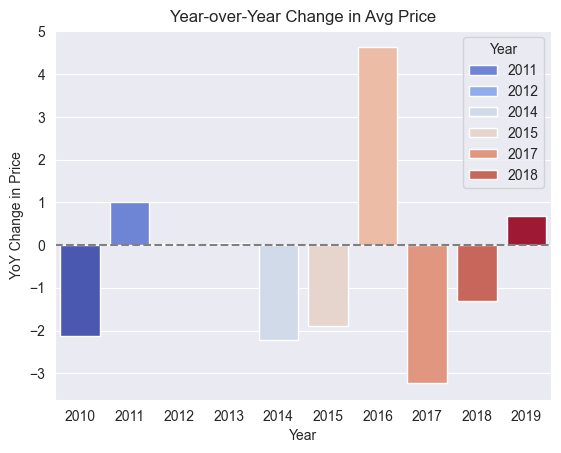

In [62]:
sns.barplot(data=price_trend_df, x="Year",hue="Year", y="YoY Change in Price", palette="coolwarm")
plt.title("Year-over-Year Change in Avg Price")
plt.axhline(0, color='gray', linestyle='--')

In [63]:
#How many unique authors/genres/books are there in this dataset?
#Even though Pandas has .nunique(), NumPy is faster for large-scale, automated pipelines and dashboards.

# Unique authors
unique_authors = np.unique(df["Author"])
print("Number of unique authors:", len(unique_authors))

# Unique genres
unique_genres = np.unique(df["Genre"])
print("Genres:", unique_genres)

# Unique book titles
unique_books = np.unique(df["Name"])
print("Total unique book titles:", len(unique_books))

#Used in ETL pipelines to filter or deduplicate
#Helps in category counts for reports or dashboards
#Much faster than .unique() in NumPy-heavy pipelines

Number of unique authors: 248
Genres: ['Fiction' 'Non Fiction']
Total unique book titles: 351


In [64]:
#What if we want to simulate book sales or customer ratings for forecasting or experiments?

# Simulate random sales (in thousands) for each book
np.random.seed(42)  # For reproducibility
df["Simulated_Sales"] = np.random.randint(10, 200, size=len(df))  # Sales in thousands

df[["Name", "Author", "Simulated_Sales"]].head()

,Name,Author,Simulated_Sales
0,10-Day Green Smoothie Cleanse,JJ Smith,112
1,11/22/63: A Novel,Stephen King,189
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,102
3,1984 (Signet Classics),George Orwell,24
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,116


In [65]:
#Simulate Ratings from a Normal Distribution
# Simulate random ratings around 4.5 with some variation
df["Simulated_Rating"] = np.round(np.random.normal(loc=4.5, scale=0.3, size=len(df)), 2)

# Cap values between 1.0 and 5.0
df["Simulated_Rating"] = df["Simulated_Rating"].clip(1.0, 5.0)

df[["Name", "Simulated_Rating"]].head()

#Great for what-if analysis or prepping ML features
#Use in A/B testing: simulate user actions under variation
#Build synthetic datasets when data is missing or limited

,Name,Simulated_Rating
0,10-Day Green Smoothie Cleanse,4.46
1,11/22/63: A Novel,4.72
2,12 Rules for Life: An Antidote to Chaos,4.36
3,1984 (Signet Classics),4.73
4,"5,000 Awesome Facts (About Everything!) (Natio...",4.81


In [2]:

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [49]:
df.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre',
       'Expensive', 'Top10_Review', 'Price_Zscore'],
      dtype='object')

In [58]:
#Distribution of User Ratings by Genre

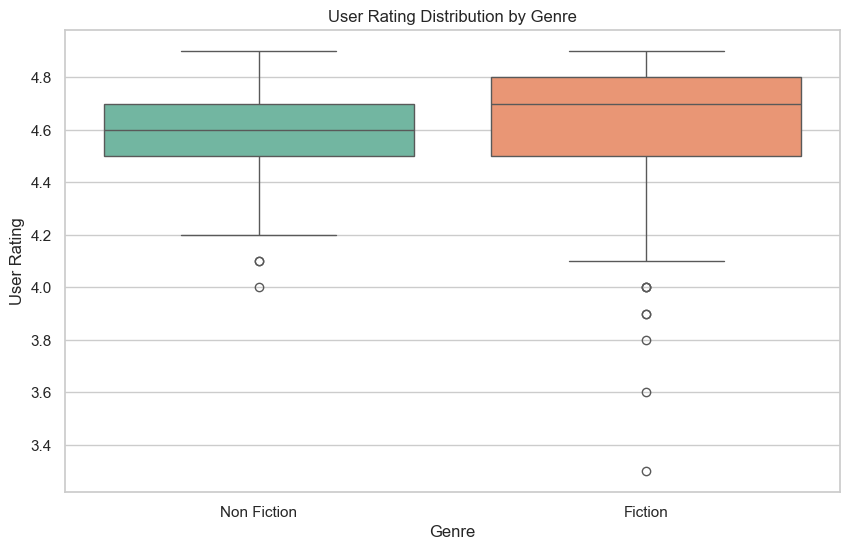

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Genre', y='User Rating',hue="Genre", palette='Set2')
plt.title('User Rating Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('User Rating')
plt.show()

C:\Users\shiva\AppData\Local\Temp\ipykernel_3332\4188979798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette='magma')


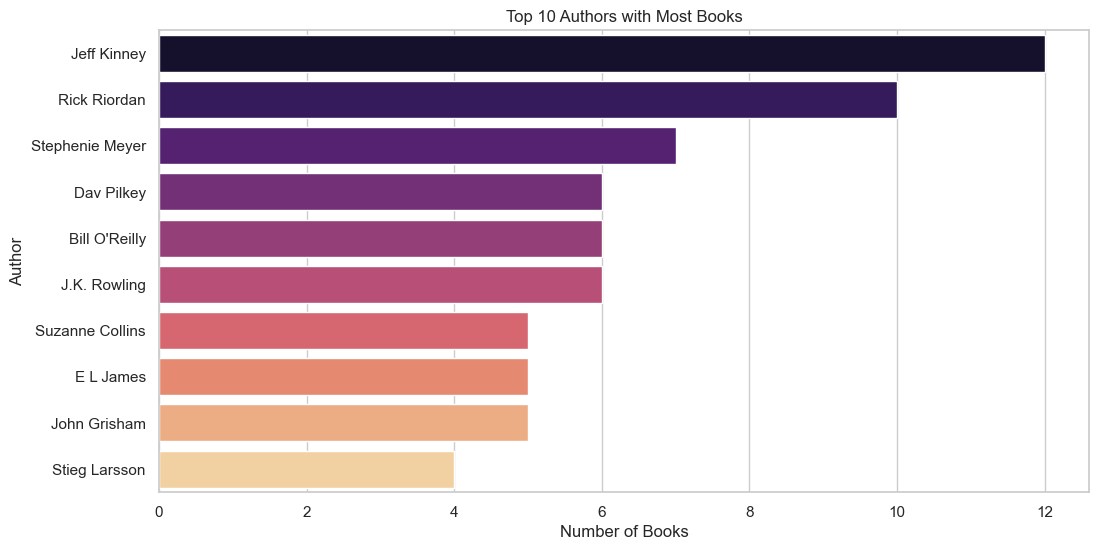

In [68]:
#Top Authors with Most Books in the Dataset
plt.figure(figsize=(12, 6))
top_authors = df['Author'].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index, palette='magma')
plt.title('Top 10 Authors with Most Books')
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.show()

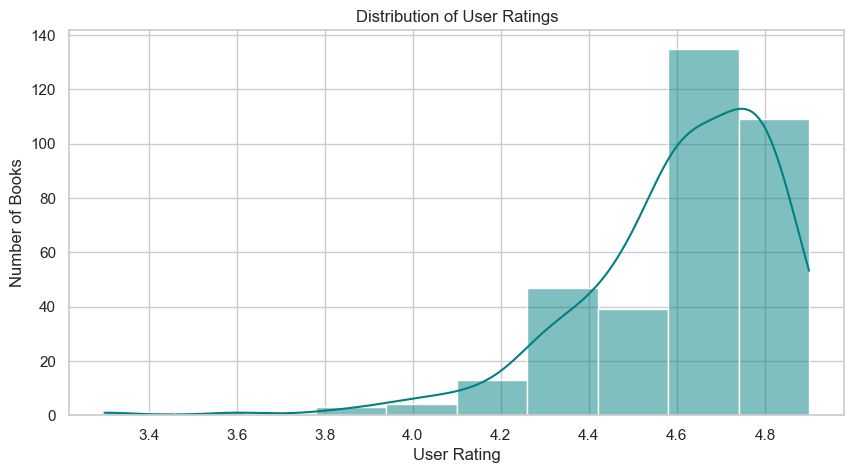

In [70]:
# User Rating Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['User Rating'], bins=10, kde=True, color='teal')
plt.title('Distribution of User Ratings')
plt.xlabel('User Rating')
plt.ylabel('Number of Books')
plt.show()
#Helps us understand how customers are rating books. Are most ratings high? Is there any bias?

C:\Users\shiva\AppData\Local\Temp\ipykernel_3332\3050846830.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_reviews, x='Reviews', y='Name', palette='viridis')


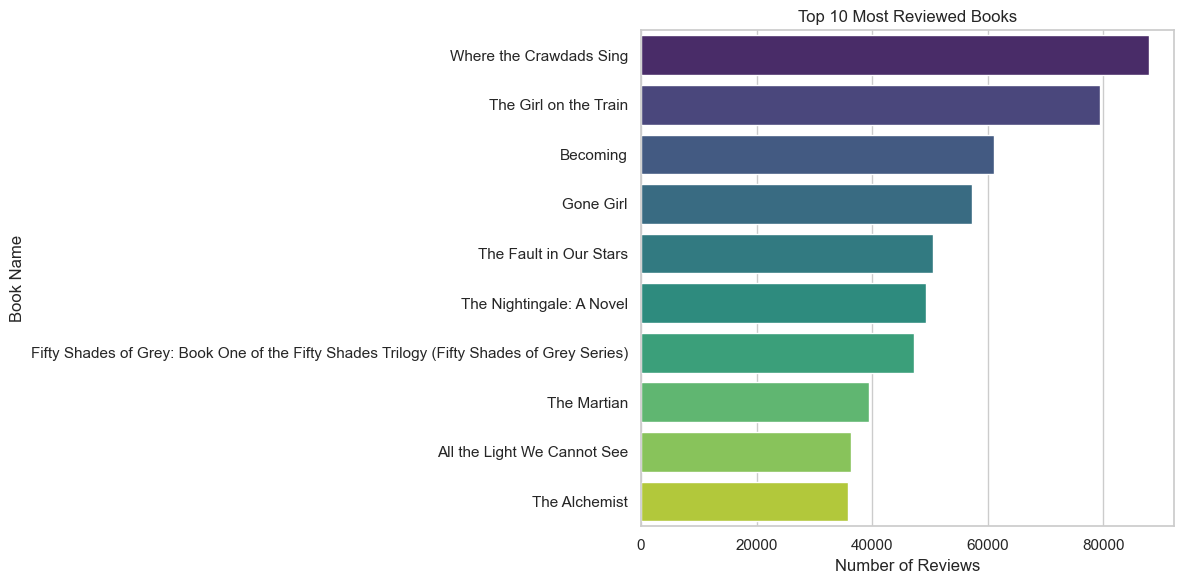

In [72]:
#Top 10 Most Reviewed Books
top10_reviews = df.sort_values(by='Reviews', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_reviews, x='Reviews', y='Name', palette='viridis')
plt.title('Top 10 Most Reviewed Books')
plt.xlabel('Number of Reviews')
plt.ylabel('Book Name')
plt.tight_layout()
plt.show()

C:\Users\shiva\AppData\Local\Temp\ipykernel_3332\530178349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Genre', y='User Rating', palette='Set2')


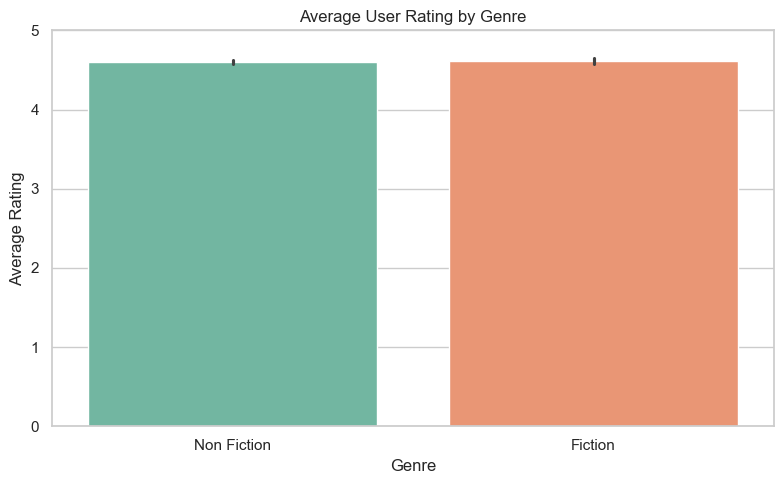

In [73]:
#Average User Rating by Genre
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Genre', y='User Rating', palette='Set2')
plt.title('Average User Rating by Genre')
plt.ylabel('Average Rating')
plt.xlabel('Genre')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [74]:
#Recommended Books to Promote
top_books = df[
    (df['User Rating'] >= 4.8) &
    (df['Reviews'] >= 10000) &
    (df['Year'] >= 2015)
].sort_values(by=['User Rating', 'Reviews'], ascending=[False, False])

top_books[['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year']]

,Name,Author,User Rating,Reviews,Price,Year
153,Harry Potter and the Chamber of Secrets: The I...,J.K. Rowling,4.9,19622,30,2016
40,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,14344,5,2017
85,Dog Man: Fetch-22: From the Creator of Captain...,Dav Pilkey,4.9,12619,8,2019
207,Last Week Tonight with John Oliver Presents A ...,Jill Twiss,4.9,11881,13,2018
157,Harry Potter and the Sorcerer's Stone: The Ill...,J.K. Rowling,4.9,10052,22,2016
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019
32,Becoming,Michelle Obama,4.8,61133,11,2018
437,The Nightingale: A Novel,Kristin Hannah,4.8,49288,11,2015
490,The Wonky Donkey,Craig Smith,4.8,30183,4,2018
325,The 5 Love Languages: The Secret to Love that ...,Gary Chapman,4.8,25554,8,2015
